In [1]:
from FIT_python.pipeline_sex.data_import_utils import load_raw_files
from FIT_python.config import RAW_DIR
raw_dfs = load_raw_files(RAW_DIR)
raw_dfs

{'Aj_Someringii':                     id            species individual_id                trail  \
 0      Aj_Someringii_1  A.j. soemmeringii          3368    3368 a 05-05-2019   
 1      Aj_Someringii_2  A.j. soemmeringii          3368    3368 a 05-05-2019   
 2      Aj_Someringii_3  A.j. soemmeringii          3368    3368 a 05-05-2019   
 3      Aj_Someringii_4  A.j. soemmeringii          3368    3368 a 05-05-2019   
 4      Aj_Someringii_5  A.j. soemmeringii          3368    3368 a 05-05-2019   
 ..                 ...                ...           ...                  ...   
 365  Aj_Someringii_366  A.j. soemmeringii        Ciaran  Ciaran b 13-04-2022   
 366  Aj_Someringii_367  A.j. soemmeringii        Ciaran  Ciaran b 13-04-2022   
 367  Aj_Someringii_368  A.j. soemmeringii          1986    1986 c 07-05-2019   
 368  Aj_Someringii_369  A.j. soemmeringii        Ciaran  Ciaran a 13-04-2022   
 369  Aj_Someringii_370  A.j. soemmeringii          Jake    Jake b 05-06-2022   
 
     sex 

In [1]:
# %% [code]
from pathlib import Path
import pandas as pd
import numpy as np
import ast
from tqdm.auto import tqdm
from joblib import Parallel, delayed
from sklearn.model_selection import ParameterSampler

from FIT_python.pipeline_sex.pipeline_wrapper_sex import PipelineWrapper
from FIT_python.config import RESULTS_DATA_DIR

# 1) Prepare (Clean → Split → Summary)
prep = PipelineWrapper(
    model_keys=["log_reg"],  # Dummy
    impute_method=None,
    outlier_method=None,
    scaler_method=None,
    reduce_pre_method=None,
    reduce_post_method=None,
    fs_method=None,
    fs_k=None,
)
prep.prepare()


ImportError: cannot import name 'create_train_test_split_otter' from partially initialized module 'FIT_python.data_split_and_summary.split_utils' (most likely due to a circular import) (C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py)

In [10]:
import pandas as pd

# Beispiel-Dateien laden
df_tiger = pd.read_parquet(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\data\raw\Amur_Tiger.parquet")
df_otter = pd.read_parquet(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\data\raw\Eurasian_Otter.parquet")

# Erste Einblicke
df_tiger_info = df_tiger[["sex"] + [c for c in df_tiger.columns if "animal" in c or "individual_id" in c]].head()
df_otter_info = df_otter[["sex"] + [c for c in df_otter.columns if "animal" in c or "individual_id" in c]].head()

df_tiger_info, df_otter_info

(  sex individual_id
 0   m          m541
 1   m          m541
 2   m          m541
 3   m          m541
 4   m          m541,
   sex individual_id
 0   f       zanetka
 1   f       zanetka
 2   f       zanetka
 3   f       zanetka
 4   f       zanetka)

In [15]:
from pathlib import Path

# Lokale Datei-Pfade (anpassen, falls du lokal arbeitest)
data_files = [
    Path(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\data\raw\Amur_Tiger.parquet"),
    Path(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\data\raw\Eurasian_Otter.parquet"),
]

results = []

for path in data_files:
    print("\n" + "="*70)
    print(f"📄 Verarbeite Datei: {path.name}")

    try:
        df = pd.read_parquet(path)
    except Exception as e:
        print(f"❌ Fehler beim Einlesen von {path.name}: {e}")
        continue

    # Debug: Spalten checken
    print(f"🔢 Spalten: {df.columns.tolist()[:10]}... ({len(df.columns)} gesamt)")

    try:
        train_df, test_df, inference_df = stratified_group_split(df)
        print(f"✅ Split erfolgreich für {path.name}")
        print(f"   🟩 Train:     {len(train_df)}")
        print(f"   🟦 Test:      {len(test_df)}")
        print(f"   🟨 Inference: {len(inference_df)}")
        results.append({
            "name": path.name,
            "train": train_df,
            "test": test_df,
            "inference": inference_df
        })
    except Exception as e:
        print(f"❌ Fehler beim Splitten von {path.name}: {e}")



📄 Verarbeite Datei: Amur_Tiger.parquet
🔢 Spalten: ['id', 'species', 'individual_id', 'trail', 'sex', 'v1', 'v2', 'v3', 'v4', 'v5']... (133 gesamt)
🔍 Starte stratified_group_split...
📌 Gruppenspalte: individual_id
📏 Ursprüngliche Größe: (605, 133)
✅ Gültige Zeilen mit Gruppen-ID und 'm'/'f': (0, 133)
👥 Gruppen mit mindestens einem 'm' und 'f': 0
📊 Für Split geeignet: (0, 133), Inference: (605, 133)
❌ Fehler beim Splitten von Amur_Tiger.parquet: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

📄 Verarbeite Datei: Eurasian_Otter.parquet
🔢 Spalten: ['id', 'species', 'individual_id', 'date', 'location', 'dataorigin', 'substrate', 'sex', 'trail', 'dist1_2']... (214 gesamt)
🔍 Starte stratified_group_split...
📌 Gruppenspalte: individual_id
📏 Ursprüngliche Größe: (628, 214)
✅ Gültige Zeilen mit Gruppen-ID und 'm'/'f': (0, 214)
👥 Gruppen mit mindestens einem 'm' und 'f': 0
📊 Für Split geeignet: (0, 214), In

In [7]:
# 📂 Pfad zum Datenordner
data_dir = Path(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\data\raw")  # z.B. Path("data/species/")
all_files = sorted(data_dir.glob("*.parquet")) + sorted(data_dir.glob("*.csv"))
print(f"🔎 {len(all_files)} Dateien gefunden")


🔎 10 Dateien gefunden


In [8]:
# 📁 Für jede Datei Split durchführen
for file_path in all_files:
    print("\n" + "="*60)
    print(f"📄 Verarbeite Datei: {file_path.name}")
    
    # 📥 Laden
    if file_path.suffix == ".csv":
        df = pd.read_csv(file_path)
    else:
        df = pd.read_parquet(file_path)
    print(f"📦 Eingeladene Daten: {df.shape}")

    # ✅ Spalten-Check
    if "individual_id" not in df.columns or "sex" not in df.columns:
        print("⚠️  'individual_id' oder 'sex' fehlt – Datei wird übersprungen.")
        continue

    # ✂️ Split durchführen
    try:
        train_df, test_df, inference_df = stratified_group_split(df)
        print("🔍 Split erfolgreich:")
        print(f"  🟩 Train:     {len(train_df)}")
        print(f"  🟦 Test:      {len(test_df)}")
        print(f"  🟨 Inference: {len(inference_df)}")
    except Exception as e:
        print(f"❌ Fehler beim Split: {e}")



📄 Verarbeite Datei: Aj_Someringii.parquet
📦 Eingeladene Daten: (370, 141)
🔍 Starte stratified_group_split...
📌 Gruppenspalte: individual_id
📏 Ursprüngliche Größe: (370, 141)
✅ Gültige Zeilen mit Gruppen-ID und 'm'/'f': (0, 141)
👥 Gruppen mit mindestens einem 'm' und 'f': 0
📊 Für Split geeignet: (0, 141), Inference: (370, 141)
❌ Fehler beim Split: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

📄 Verarbeite Datei: Amur_Tiger.parquet
📦 Eingeladene Daten: (605, 133)
🔍 Starte stratified_group_split...
📌 Gruppenspalte: individual_id
📏 Ursprüngliche Größe: (605, 133)
✅ Gültige Zeilen mit Gruppen-ID und 'm'/'f': (0, 133)
👥 Gruppen mit mindestens einem 'm' und 'f': 0
📊 Für Split geeignet: (0, 133), Inference: (605, 133)
❌ Fehler beim Split: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

📄 Verarbeite Datei: Bengal_t


📥 Schritt 1: Datenimport & Cleaning
[REPORT] cleaned Aj_Someringii: shape=(370, 141)
[REPORT] cleaned Amur_Tiger: shape=(605, 133)
[REPORT] cleaned Bengal_tiger: shape=(586, 133)
[REPORT] cleaned cheetah: shape=(781, 141)
[REPORT] cleaned Eurasian_Otter: shape=(628, 214)
[REPORT] cleaned Giant_Panda: shape=(523, 129)
[REPORT] cleaned Jubatus: shape=(566, 141)
[REPORT] cleaned Lowlandtapir: shape=(426, 126)
[REPORT] cleaned Mountain_Lion: shape=(535, 138)
[REPORT] cleaned White_Rhino: shape=(1273, 117)
[SUCCESS] clean_all completed.

✂️ Schritt 2: Splitting & Fold-Zuordnung
✅ Fold-Methode verwendet: stratified_group
Fold
0     99
1     90
2    104

📊 aj_someringii – train – 293 Zeilen | 20 Individuen | 42 Trails
sex
f    161
m    132

📊 aj_someringii – test – 77 Zeilen | 5 Individuen | 11 Trails
sex
m    49
f    28

📊 aj_someringii – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ aj_someringii gespeichert (csv & parquet)
✅ Fold-Methode verwendet: stratified_group
Fold
0

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\split_utils.py:162: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["Fold"] = fold_ids
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\split_utils.py:162: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["Fold"] = fold_ids



📊 eurasian_otter – train – 379 Zeilen | 27 Individuen | 51 Trails
sex
f    214
m    165

📊 eurasian_otter – test – 168 Zeilen | 14 Individuen | 22 Trails
sex
f    92
m    76

📊 eurasian_otter – inference – 81 Zeilen | 8 Individuen | 8 Trails
sex
unknown    81

✅ eurasian_otter gespeichert (csv & parquet)
✅ Fold-Methode verwendet: stratified_group
Fold
0    152
1    181
2     90

📊 giant_panda – train – 423 Zeilen | 33 Individuen | 62 Trails
sex
f    238
m    185

📊 giant_panda – test – 100 Zeilen | 9 Individuen | 15 Trails
sex
f    63
m    37

📊 giant_panda – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ giant_panda gespeichert (csv & parquet)
✅ Fold-Methode verwendet: stratified_group
Fold
0    160
1    154
2    140

📊 jubatus – train – 454 Zeilen | 32 Individuen | 65 Trails
sex
f    265
m    189

📊 jubatus – test – 112 Zeilen | 8 Individuen | 16 Trails
sex
f    63
m    49

📊 jubatus – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ jubatus gespeichert

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\split_utils.py:162: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["Fold"] = fold_ids
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\split_utils.py:162: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["Fold"] = fold_ids



📊 eurasian_otter – train – 379 Zeilen | 27 Individuen | 51 Trails
sex
f    214
m    165

📊 eurasian_otter – test – 168 Zeilen | 14 Individuen | 22 Trails
sex
f    92
m    76

📊 eurasian_otter – inference – 81 Zeilen | 8 Individuen | 8 Trails
sex
unknown    81

✅ eurasian_otter gespeichert (csv & parquet)
✅ Fold-Methode verwendet: stratified_group
Fold
0    152
1    181
2     90

📊 giant_panda – train – 423 Zeilen | 33 Individuen | 62 Trails
sex
f    238
m    185

📊 giant_panda – test – 100 Zeilen | 9 Individuen | 15 Trails
sex
f    63
m    37

📊 giant_panda – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ giant_panda gespeichert (csv & parquet)
✅ Fold-Methode verwendet: stratified_group
Fold
0    160
1    154
2    140

📊 jubatus – train – 454 Zeilen | 32 Individuen | 65 Trails
sex
f    265
m    189

📊 jubatus – test – 112 Zeilen | 8 Individuen | 16 Trails
sex
f    63
m    49

📊 jubatus – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ jubatus gespeichert

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:   16.8s
[Parallel(n_jobs=8)]: Done   8 out of  20 | elapsed:   42.2s remaining:  1.1min
[Parallel(n_jobs=8)]: Done  11 out of  20 | elapsed:   47.8s remaining:   39.1s
[Parallel(n_jobs=8)]: Done  14 out of  20 | elapsed:  1.0min remaining:   26.1s
[Parallel(n_jobs=8)]: Done  17 out of  20 | elapsed:  1.2min remaining:   12.5s
[Parallel(n_jobs=8)]: Done  20 out of  20 | elapsed:  1.6min finished
C:\Users\Frede\AppData\Local\Temp\ipykernel_9360\1100719298.py:120: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat(results, ignore_index=True)


Fertig! Siehe:
 • C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\sex_model\raw_results.csv


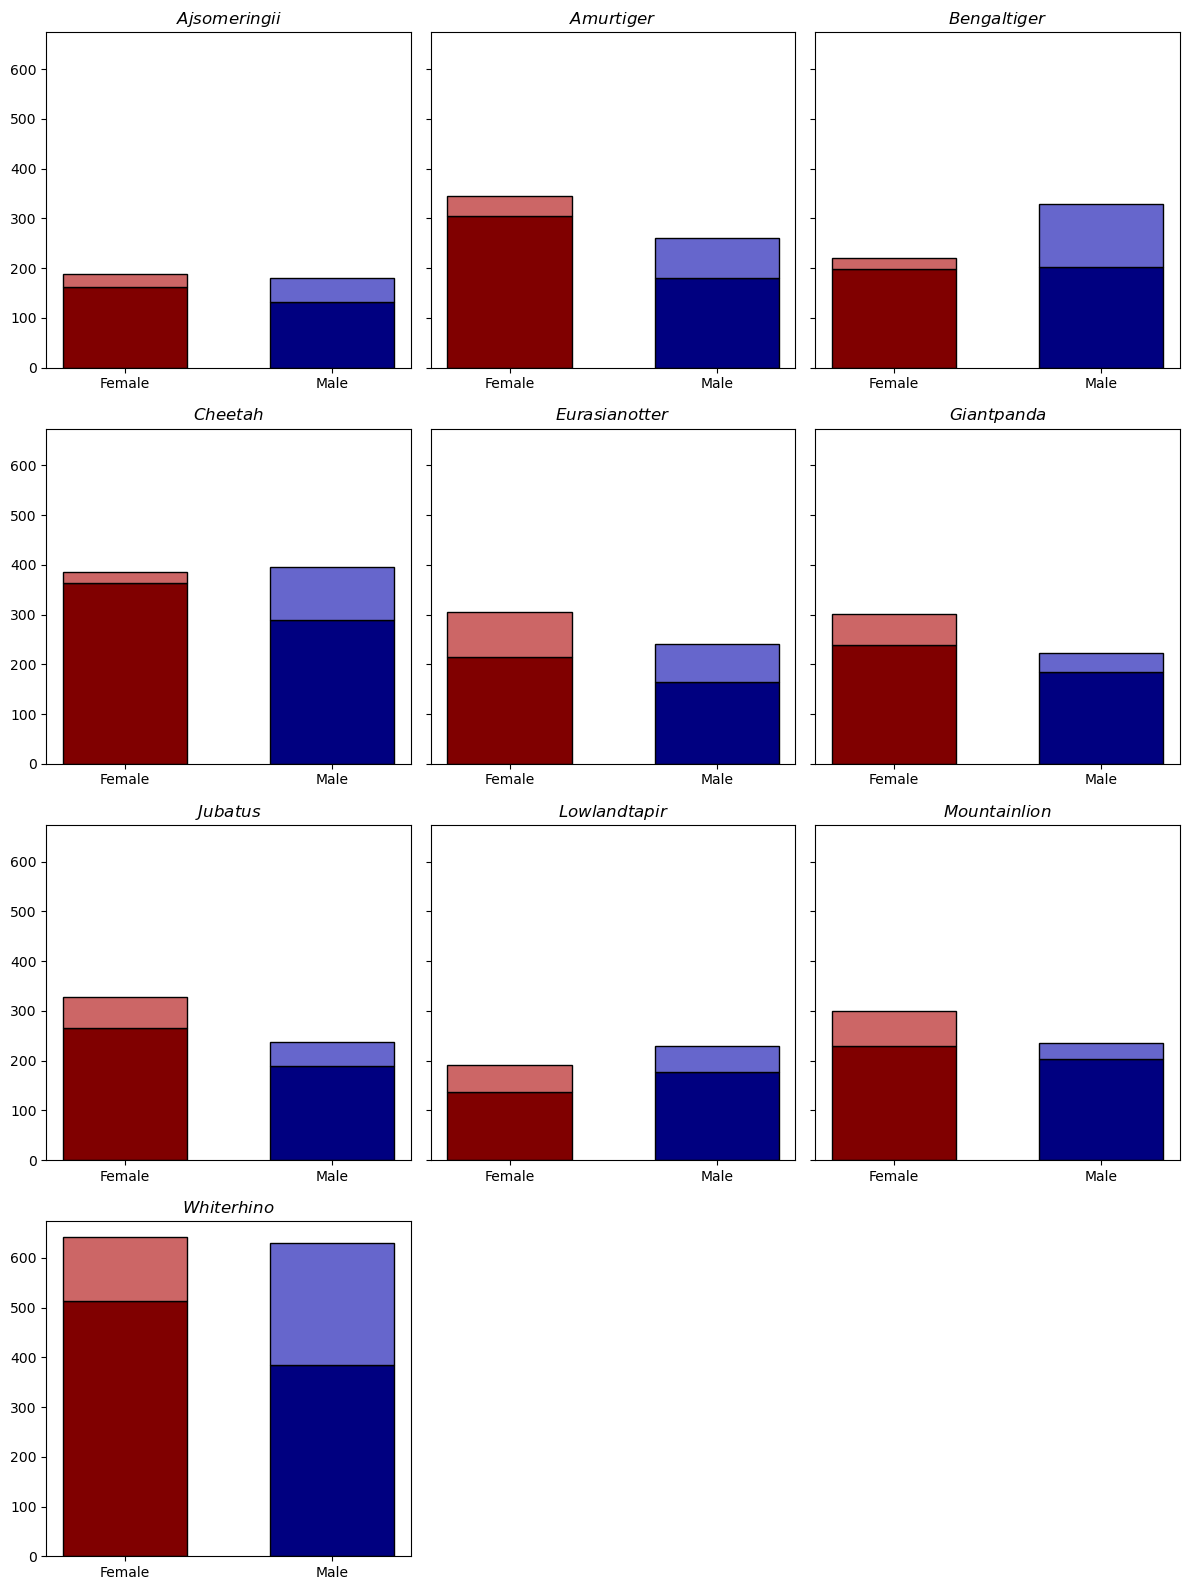

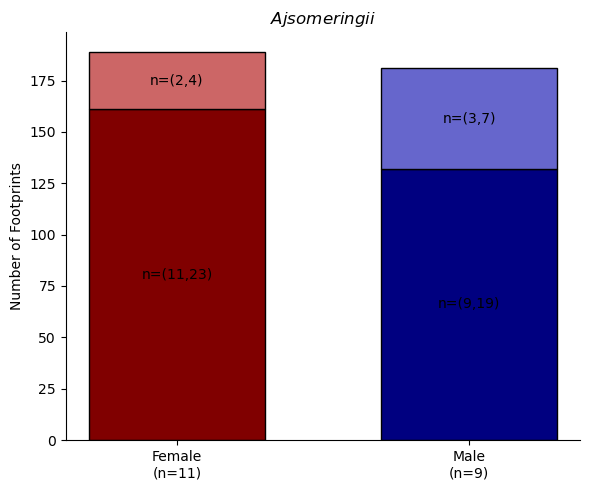

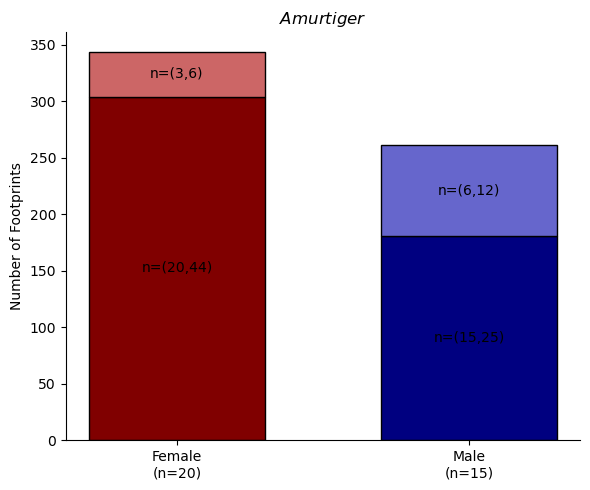

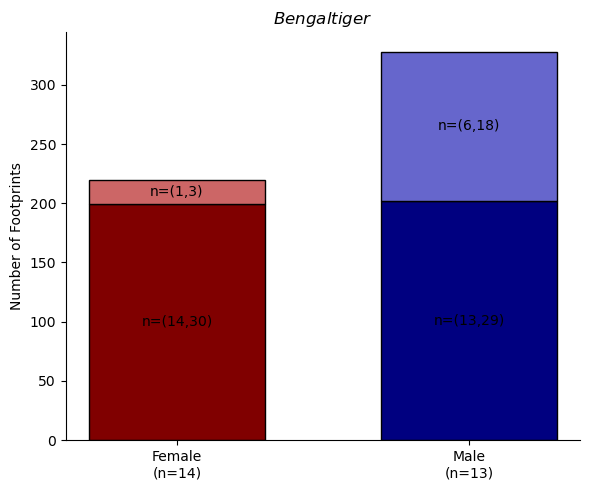

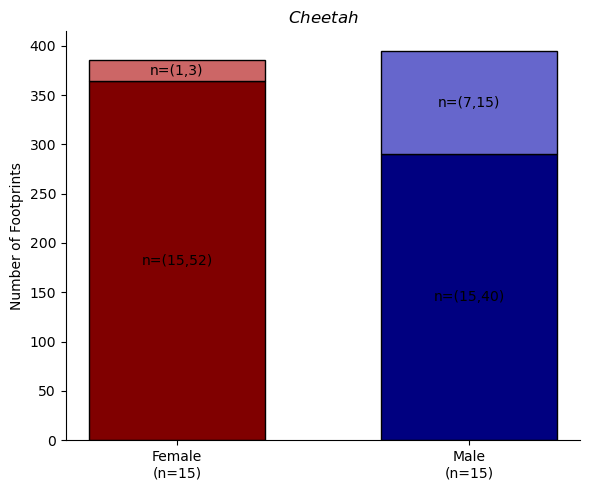

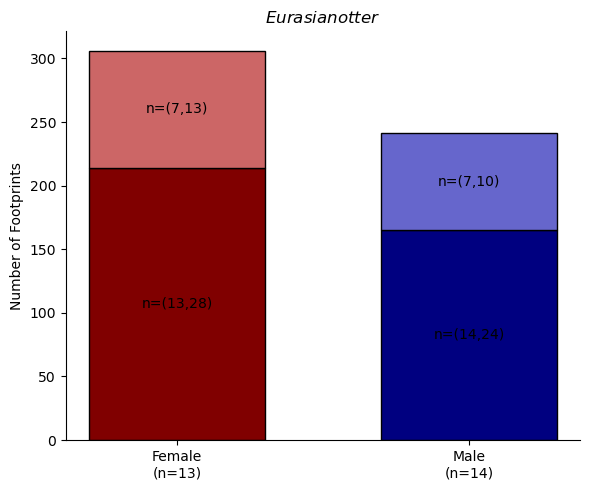

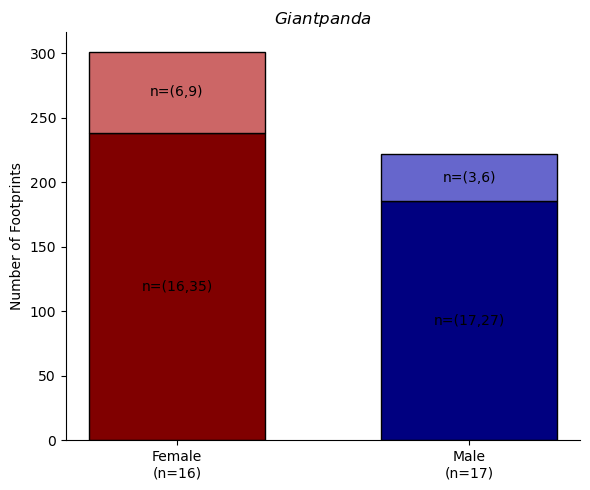

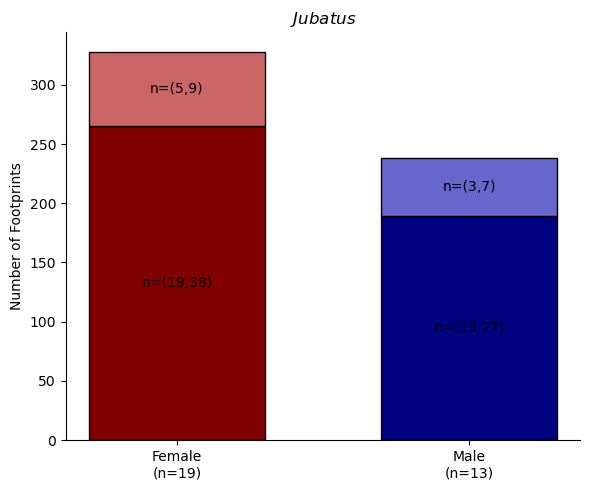

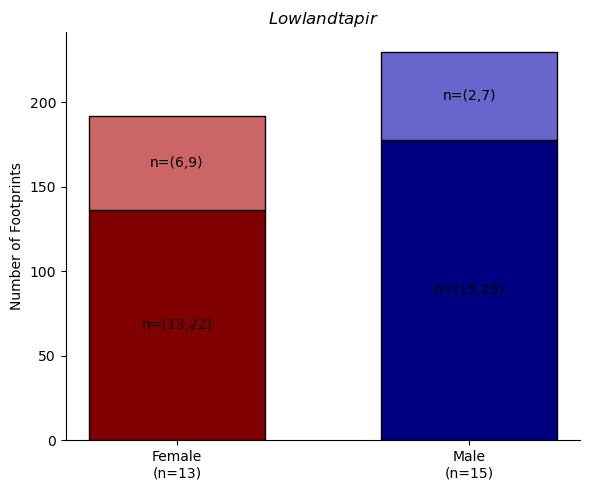

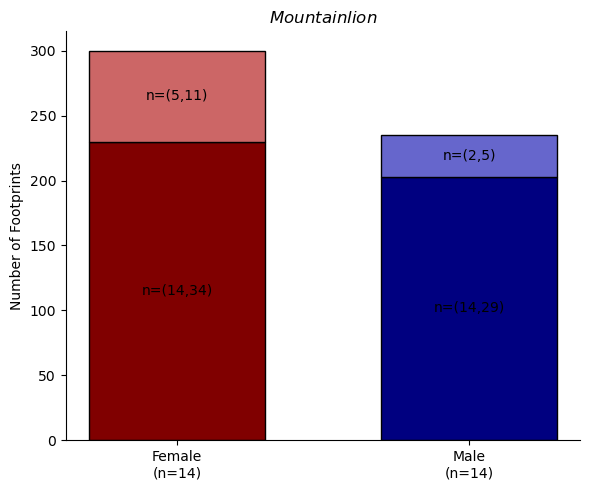

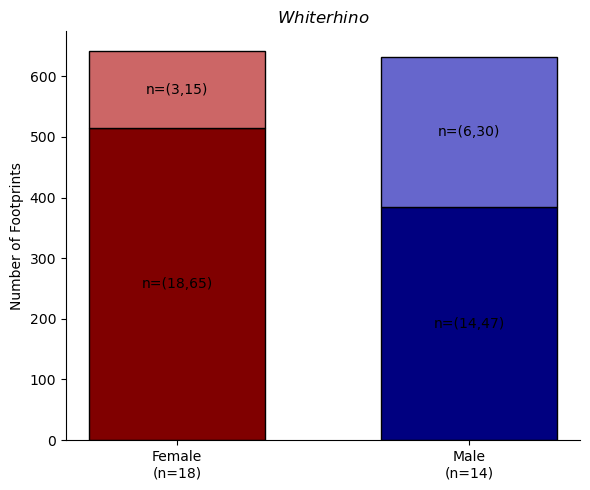

In [3]:
# %% [code]
from pathlib import Path
import pandas as pd
import numpy as np
import ast
from tqdm.auto import tqdm
from joblib import Parallel, delayed
from sklearn.model_selection import ParameterSampler

from FIT_python.pipeline_sex.pipeline_wrapper_sex import PipelineWrapper
from FIT_python.config import RESULTS_DATA_DIR

# 1) Prepare (Clean → Split → Summary)
prep = PipelineWrapper(
    model_keys=["log_reg"],  # Dummy
    impute_method=None,
    outlier_method=None,
    scaler_method=None,
    reduce_pre_method=None,
    reduce_post_method=None,
    fs_method=None,
    fs_k=None,
    validation_strategy="custom"
)
prep.prepare()

# 2) Output-Dateien
# Ergebnisse-Basis
res_dir = Path(RESULTS_DATA_DIR) / "sex_model"

# Stelle sicher, dass der Ordner da ist
res_dir.mkdir(parents=True, exist_ok=True)

# Datei-Pfade
raw_csv  = res_dir / "raw_results.csv"
best_csv = res_dir / "best_results.csv"

# Alte Dateien löschen
if raw_csv.exists():  raw_csv.unlink()
if best_csv.exists(): best_csv.unlink()

# 3) Parametrierräume
# Verfügbare Model-Keys aus MODELS
model_keys = [
    "logreg_l2", "logreg_l1",
    "rf_small", "rf_med", "rf_large",
    "et_med", "et_sm",
    "knn_3", "knn_5", "knn_7",
    "svm_linear", "svm_rbf",
    "xgb_std", "xgb_hist",
    "lgbm_std", "lgbm_md10",
    "catb_std", "catb_fast","lda",
]

param_dist = {
    "impute_method":      [None],
    "outlier_method":     [None, "clip", "zscore"],
    "scaler_method":      [None, "standard", "robust"],
    "reduce_pre_method":  [None, "pca", "umap"],
    "reduce_post_method": [None, "pca", "umap"],
    "fs_method":          [None, "forward", "random_forest", "variance", "univariate", "lasso"],
    "fs_k":               [0, 1, 2, 3, 4, 5, 6, 7, 10, 20, 50, 100],
    "model_key":          model_keys,
}
# nur 100 zufällige Kombinationen
grid = list(ParameterSampler(param_dist, n_iter=20, random_state=42))


# Hilfsfunktion für NaN→None
def clean_none(x):
    return None if pd.isna(x) else x

def run_trial(params):
    """Ein einzelner Trial, gibt DataFrame mit raw_results zurück."""
    # a) Parameter in Python-Typen
    impute   = clean_none(params["impute_method"])
    outlier  = clean_none(params["outlier_method"])
    scaler   = clean_none(params["scaler_method"])
    red_pre  = clean_none(params["reduce_pre_method"])
    red_post = clean_none(params["reduce_post_method"])
    fs_meth  = clean_none(params["fs_method"])
    fs_k_raw = params["fs_k"]
    fs_k     = None if (pd.isna(fs_k_raw) or fs_k_raw == 0) else int(fs_k_raw)
    model    = clean_none(params["model_key"])

    # b) Pipeline trainieren
    pw = PipelineWrapper(
        model_keys=[model],
        impute_method=     impute,
        outlier_method=    outlier,
        scaler_method=     scaler,
        reduce_pre_method= red_pre,
        reduce_post_method=red_post,
        fs_method=         fs_meth,
        fs_k=              fs_k,
        validation_strategy="custom"
    )
    df_raw = pw.train()

    # c) classification_report evtl. parsen
    df_raw["classification_report"] = df_raw["classification_report"].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )
    # d) Balanced Accuracy berechnen
    df_raw["balanced_accuracy"] = df_raw["classification_report"].apply(
        lambda cr: cr["macro avg"]["recall"]
    )
    # e) Metadaten anhängen
    for k, v in params.items():
        df_raw[k] = v

    return df_raw

# 4) Parallel ausführen
results = Parallel(n_jobs=8, verbose=10)(
    delayed(run_trial)(p) for p in grid
)

# 5) Alle Ergebnisse zusammenführen und CSV schreiben
df_all = pd.concat(results, ignore_index=True)
df_all.to_csv(raw_csv, index=False)

# 6) Besten Parameter-Satz bestimmen und speichern
# (oder alternativ: df_all.groupby(...).mean().idxmax())

print("Fertig! Siehe:")
print(f" • {raw_csv}")


In [ ]:
import pandas as pd
from joblib import load

# Pfade definieren
model_path = "C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/results/data/sex_models_best/eurasian_otter.joblib"
data_path  = "C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/data/raw/Eurasian Otter.csv"
output_csv = "C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/results/data/eurasian_otter_predictions.csv"

# Modell laden
clf = load(model_path)

# Daten laden
df = pd.read_csv(data_path)

# Feature-Spalten wählen (wie im Pipeline-Code)
feature_cols = [
    c for c in df.columns 
    if c.startswith(("dist", "ang", "t")) and pd.api.types.is_numeric_dtype(df[c])
]

# Merkmale extrahieren und Vorhersagen durchführen
X = df[feature_cols]
df["predicted_sex"]     = clf.predict(X)
probas = clf.predict_proba(X)
df["predicted_proba_f"] = probas[:, 0]
df["predicted_proba_m"] = probas[:, 1]

# Ergebnisse als CSV speichern
df.to_csv(output_csv, index=False)

print(f"Ergebnisse gespeichert in: {output_csv}")
